**MOVIE INDUSTRY STRATEGIC ANALYSIS**

**Project Team Members & Contributions**

Charity Nduati

Jackline Mwau

Victor Githinji

Dorcas Ndambuki

Clare Simiyu

**1.OVERVIEW**

The project analyses different types of films from movie datasets to help the head of the company decide on the type of the film to create in the new movie studio.The project analysis will focus on establishing the best performing films in the industry based on the data provided. We analyzeover 10 years of historical data to determine which factors—specifically Genre, Production Budget, and Release Timing—drive the highest Return on Investment (ROI) and total worldwide revenue.

**Methodology**
Our team utilized a structured Data Science workflow:

Data Cleaning:Standardizing currency, handling missing values, and formatting dates.

Exploratory Data Analysis (EDA):Visualizing trends in profitability across genres and time.


**2.BUSINESS UNDERSTANDING**

The company wants to enter the movie industry, but they lack experience. The goal of this project is to analyze existing movie data to identify patterns of success and guide decision-making for the new studio

**2.1 Key Business Questions:**
To guide the studio's launch, this analysis answers the following:

Genre Selection: Which film genres consistently outperform others in terms of revenue?

Budget Optimization: Is there a "sweet spot" for production budgets that balances risk and reward?

Market Timing: When is the most profitable time of year to release a new feature film?

**2.2 Goal**

Provide data-driven recommendations so the company can:

Reduce risk when investing in movies

Choose the right type of films

Maximize profit and audience reach

**3.DATA UNDERSTANDING**

We used three main data sources:

1.[bom.movie_gross.csv.gz](zippedData/bom.movie_gross.csv.gz)-it shows gross revenue (movies that made the most revenue,studios that produced the highest films)

2.[im.db.zip](zippedData/im.db.zip)-shows the movie genres produced,runtime,year,title and ratings.

3.[tn.movie_budgets.csv.gz](zippedData/tn.movie_budgets.csv.gz)-shows has the movies production budgets,therefore we use to determine the cost and return on investment

**4.DATA PREPARATION AND IMPORTING LIBRARIES**

4.1 Data Loading

In [2]:

#importing libraries
import pandas as pd
import numpy as np
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

In [3]:
#loading data
bom=pd.read_csv('zippedData/bom.movie_gross.csv.gz')
bom

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


In [4]:
#connecting the im.db.zip data
conn = sqlite3.connect('zippedData im.db.zip')
conn

In [5]:
#defining the path for the data
zip_path = ("im.db.zip")
extract_path = "./"

In [6]:
# Unzip file 
if not os.path.exists('zippedData/im.db'):
    with zipfile.ZipFile('zippedData/im.db.zip', 'r') as zip_ref:
        zip_ref.extractall('zippedData/')
    print("Database unzipped successfully!")

In [7]:
# Connect and list all tables
conn = sqlite3.connect('zippedData/im.db')
cursor = conn.cursor()
tables=pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';",conn)
print(tables)

            name
0   movie_basics
1      directors
2      known_for
3     movie_akas
4  movie_ratings
5        persons
6     principals
7        writers


In [8]:

#Using sqlite3 with pandas
#df=pd.read_sql(query,conn)
#Using sqlite3 with pandas
#df=pd.read_sql(query,conn)
movie_basics=pd.read_sql('SELECT * FROM movie_basics',conn)
movie_basics.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [9]:
#Using sqlite3 with pandas
#df=pd.read_sql(query,conn)
movie_ratings=pd.read_sql('SELECT * FROM movie_ratings',conn)
movie_ratings.head()

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [10]:
tn=pd.read_csv('zippedData/tn.movie_budgets.csv.gz')
tn

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


**4.2 DETAILED DATA CLEANING**


In [11]:
#cleaning the bom.movie_gross.csv.gz
#Data Inspecting
def inspect(df, name):
    print(f"\n--- {name} ---")
    print(df.head())
    print(df.info())
    print(df.describe(include='all'))
inspect(bom, 'BOM Movie Gross')
inspect(tn, 'TN Movie Budgets')
inspect(tables, 'IMDB Movies')


--- BOM Movie Gross ---
                                         title studio  domestic_gross  \
0                                  Toy Story 3     BV     415000000.0   
1                   Alice in Wonderland (2010)     BV     334200000.0   
2  Harry Potter and the Deathly Hallows Part 1     WB     296000000.0   
3                                    Inception     WB     292600000.0   
4                          Shrek Forever After   P/DW     238700000.0   

  foreign_gross  year  
0     652000000  2010  
1     691300000  2010  
2     664300000  2010  
3     535700000  2010  
4     513900000  2010  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year       

In [12]:
# check missing values in each dataset
print("BOM Movie Gross missing values:")
print(bom.isnull().sum())
print("\nTN Movie Budgets missing values:")
print(tn.isnull().sum())
print("\nIMDB Movies (movie_basics) missing values:")
print(tables.isnull().sum())

BOM Movie Gross missing values:
title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

TN Movie Budgets missing values:
id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

IMDB Movies (movie_basics) missing values:
name    0
dtype: int64


In [13]:
## Establishing the data types of foreign gross
bom['foreign_gross'].dtype

dtype('O')

In [14]:
#Establishing the data types of domestic gross
bom['domestic_gross'].dtype

dtype('float64')

In [15]:
#Establishing the data types of domestic gross
bom['studio'].dtype

dtype('O')

In [16]:
#Converting foreign_gross
bom['foreign_gross'] = pd.to_numeric(bom['foreign_gross'], errors='coerce')

In [17]:
#Converting Date into Datetime
#For bom.movie_gross data, we are using the year column
# Convert Year to integer
bom['year'] = bom['year'].astype(int)
#For tn.movie_budgets, we format the release_date column
tn['release_date'] = pd.to_datetime(tn['release_date'])
#Extract Month and Year
tn['release_month'] = tn['release_date'].dt.month
tn['release_year'] = tn['release_date'].dt.year

In [18]:
# Clean TN Movie Budgets 
# Remove $ and commas
cols = ['production_budget', 'domestic_gross', 'worldwide_gross']
for col in cols:
    
    tn[col] = tn[col].replace({'\$': '', ',': ''}, regex=True)
    tn[col] = pd.to_numeric(tn[col], errors='coerce')

In [19]:
#Clean Movie_basics  Data
movie_basics.columns

Index(['movie_id', 'primary_title', 'original_title', 'start_year',
       'runtime_minutes', 'genres'],
      dtype='object')

In [20]:
# Keep only relevant columns
movie_basics = movie_basics[['movie_id', 'primary_title', 'original_title', 'start_year',
       'runtime_minutes', 'genres']]
# Rename for merging
movie_basics.rename(columns={'primary_title': 'title'}, inplace=True)

In [21]:
#checking columns in movie_ratings data
movie_ratings.columns

Index(['movie_id', 'averagerating', 'numvotes'], dtype='object')

In [22]:
# Cleaning Movie_ratings data
# Merge ratings with movie_basics
ratings_basics = pd.merge(movie_basics, movie_ratings, on='movie_id', how='inner')

In [23]:
# Lowercase titles for consistency
bom['title'] = bom['title'].str.lower()
tn['movie'] = tn['movie'].str.lower()
ratings_basics['title'] = ratings_basics['title'].str.lower()

In [24]:
#Replacing missing values
#Replacing studio value
bom['studio']=bom['studio'].fillna('unknown')
#Replacing domestic_grosss missing values
domestic_median=bom['domestic_gross'].median()
bom['domestic_gross'] = bom['domestic_gross'].fillna(domestic_median)
#Replacing foreign_grosss missing values
foreign_mean = bom['foreign_gross'].mean()
bom['foreign_gross'] = bom['foreign_gross'].fillna(foreign_mean)

In [25]:
# Merging Datasets
# Merge revenue + budget
merged = pd.merge(
    bom,
    tn,
    left_on='title',
    right_on='movie',
    how='inner'
)

In [26]:
# Merge with ratings
merged_1 = pd.merge(
    merged,
    ratings_basics,
    on='title',
    how='inner'
)

In [27]:
#Final Data Cleaning on the merged dataset
merged_1.isnull().sum()
merged_1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1471 entries, 0 to 1470
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   title              1471 non-null   object        
 1   studio             1471 non-null   object        
 2   domestic_gross_x   1471 non-null   float64       
 3   foreign_gross      1471 non-null   float64       
 4   year               1471 non-null   int32         
 5   id                 1471 non-null   int64         
 6   release_date       1471 non-null   datetime64[ns]
 7   movie              1471 non-null   object        
 8   production_budget  1471 non-null   int64         
 9   domestic_gross_y   1471 non-null   int64         
 10  worldwide_gross    1471 non-null   int64         
 11  release_month      1471 non-null   int64         
 12  release_year       1471 non-null   int64         
 13  movie_id           1471 non-null   object        
 14  original

In [28]:
#Validate the Merge
merged_1.shape

(1471, 20)

In [29]:
#Standardize data formats
# Make sure string columns are consistent
merged_1['title'] = merged_1['title'].astype(str)
merged_1['studio'] = merged_1['studio'].astype(str)

In [30]:
#Check duplicates in merged dataset
merged_1.duplicated().sum()

0

In [31]:
#Display the duplicate rows
merged_1[merged_1.duplicated()]

,title,studio,domestic_gross_x,foreign_gross,year,id,release_date,movie,production_budget,domestic_gross_y,worldwide_gross,release_month,release_year,movie_id,original_title,start_year,runtime_minutes,genres,averagerating,numvotes


In [32]:
#Check duplicates based on key column(title,release year)
merged_1.duplicated(subset=['title','movie_id', 'release_year']).sum()

0

In [33]:
#Check using multiple columns
merged_1.duplicated(subset=['title', 'movie_id','release_year']).sum()

0

In [34]:
#view duplicates
merged_1[merged_1.duplicated(subset=['title','movie_id', 'release_year'], keep=False)]

,title,studio,domestic_gross_x,foreign_gross,year,id,release_date,movie,production_budget,domestic_gross_y,worldwide_gross,release_month,release_year,movie_id,original_title,start_year,runtime_minutes,genres,averagerating,numvotes


In [35]:
#Remove duplicates
# Check duplicates first
merged_1[merged_1.duplicated(subset=['title', 'release_year'], keep=False)]
# Drop duplicates (keep first)
merged_1 = merged_1.drop_duplicates(subset=['title', 'release_year'], keep='first')

In [36]:
#standardize string values
merged_1['studio'] = merged_1['studio'].str.lower().str.strip()
merged_1['title'] = merged_1['title'].str.strip()

In [37]:
#filter out bad data
# Example: remove movies with zero or negative budgets
merged_1 = merged_1[merged_1['production_budget'] > 0]
# Remove rows with negative or zero gross
merged_1 = merged_1[merged_1['worldwide_gross'] > 0]

In [38]:
# remove top 1% extreme domestic gross values
domestic_upper = merged_1['domestic_gross_y'].quantile(0.99)
merged_1 = merged_1[merged_1['domestic_gross_y'] <= domestic_upper]

In [39]:
#rename column
merged_1 = merged_1.rename(columns={
    'domestic_gross_x': 'domestic_gross_old_source',
    'domestic_gross_y': 'domestic_gross',
    'release_year': 'year_released'
})

In [40]:
#save cleaned data
merged_1.to_csv('cleaned_merged_data.csv', index=False)

**TOTAL REVENUE BIGGEST SUCCESS METRICS**

In [41]:
# Create total gross:
bom['total_gross'] = bom['domestic_gross'] + bom['foreign_gross']

In [42]:
# Top-performing movies
# Focus on high-revenue genres
bom.sort_values('total_gross', ascending=False).head(10)

,title,studio,domestic_gross,foreign_gross,year,total_gross
727,marvel's the avengers,BV,623400000.0,895500000.0,2012,1.518900e+09
1875,avengers: age of ultron,BV,459000000.0,946400000.0,2015,1.405400e+09
3080,black panther,BV,700100000.0,646900000.0,2018,1.347000e+09
328,harry potter and the deathly hallows part 2,WB,381000000.0,960500000.0,2011,1.341500e+09
2758,star wars: the last jedi,BV,620200000.0,712400000.0,2017,1.332600e+09
3081,jurassic world: fallen kingdom,Uni.,417700000.0,891800000.0,2018,1.309500e+09
1127,frozen,BV,400700000.0,875700000.0,2013,1.276400e+09
2759,beauty and the beast (2017),BV,504000000.0,759500000.0,2017,1.263500e+09
3082,incredibles 2,BV,608600000.0,634200000.0,2018,1.242800e+09
1128,iron man 3,BV,409000000.0,805800000.0,2013,1.214800e+09


In [43]:
# Studio performance
bom.groupby('studio')['total_gross'].mean().sort_values(ascending=False)/1_000_000
#in millions of dollars

studio
HC              870.300000
P/DW            507.650000
BV              419.934996
GrtIndia        254.200000
WB (NL)         231.327934
                   ...    
FOAK              0.124300
IVP               0.112100
Darin Southa      0.098400
ITL               0.052900
WOW               0.049400
Name: total_gross, Length: 258, dtype: float64

In [44]:
# Yearly trends
bom.groupby('year')['total_gross'].mean()/1_000_000
# Is revenue growing over time

year
2010     78.015192
2011     84.446092
2012     97.957123
2013    109.414272
2014     98.985473
2015    102.048230
2016    111.159728
2017    130.198792
2018    125.887847
Name: total_gross, dtype: float64

In [45]:
# Domestic vs Foreign market
# Global appeal is critical
# Think globally, not locally
bom[['domestic_gross', 'foreign_gross']].mean()/1_000_000

domestic_gross    28.519780
foreign_gross     75.057042
dtype: float64

In [46]:
# Budget vs revenue (if merged with tn dataset)
# Budget strategically
# High budget ≠ guaranteed success
# ROI matters more than revenue
merged_1['profit'] = merged_1['worldwide_gross'] - merged_1['production_budget']
# ROI
merged_1['roi'] = merged_1['profit'] / merged_1['production_budget']

In [47]:
# Learn from top studios
# Genre choices, Release timing and Franchise strategy

To maximize box office success, the studio should prioritize high-budget action and adventure films with global appeal. These genres consistently generate the highest revenues, especially in international markets. Additionally, investing in franchise-based content and focusing on return on investment rather than just total revenue will improve long-term profitability.

**5.DATA ANALYSIS AND VISUALIZATION**

In [48]:
# Create total gross:
bom['total_revenue'] = bom['domestic_gross'] + bom['foreign_gross']

In [49]:
# Budget vs revenue (if merged with tn dataset)
# Budget strategically
# High budget ≠ guaranteed success
# ROI matters more than revenue
merged_1['profit'] = merged_1['worldwide_gross'] - merged_1['production_budget']
# ROI
merged_1['roi'] = merged_1['profit'] / merged_1['production_budget']

In [50]:
# Top 20 performing movies in terms of profitability
top_10=(merged_1[['title', 'profit', 'roi']].sort_values(by='profit', ascending=False)).head(10)
top_10

,title,profit,roi
860,furious 7,1328722794,6.993278
536,frozen,1122469910,7.483133
862,minions,1086336173,14.680219
1358,aquaman,986894640,6.168092
1213,the fate of the furious,984846267,3.939385
1214,despicable me 3,959727750,12.796370
186,transformers: dark of the moon,928790543,4.763028
382,skyfall,910526981,4.552635
540,despicable me 2,899216835,11.831800
692,transformers: age of extinction,894039076,4.257329


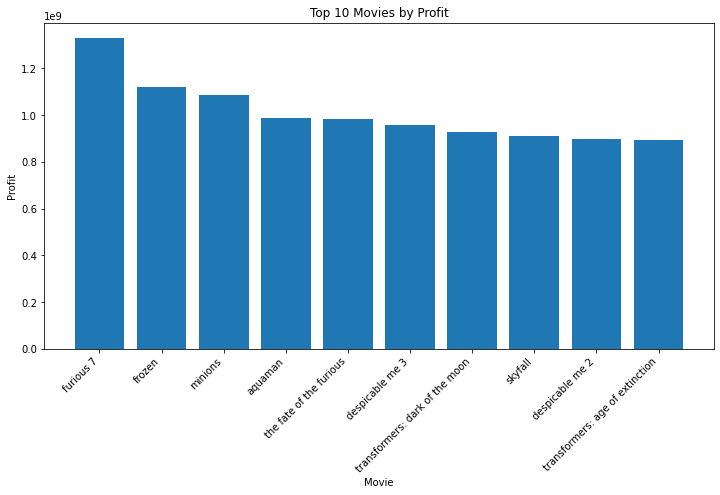

In [51]:
# Visualizing the top_10 movies based on profits
plt.figure(figsize=(12,6))
plt.bar(top_10['title'], top_10['profit'])
plt.title("Top 10 Movies by Profit")
plt.xlabel("Movie")
plt.ylabel("Profit")
plt.xticks(rotation=45, ha='right')
plt.show()

Insight: Profit Distribution Among Top 10 Movies

The bar chart reveals that profitability among the top 10 movies is not evenly distributed. A number of movies generate higher profits compared to the rest.

Although all selected movies are high-performing, the visible gaps between profit levels suggest that there is competition even in the top-tier group. This means that for high profits, the productions should standout due to competitive nature in performances.

In [52]:
# Analysing seasonal success to determine the best time of the year to release our movies
monthly_profit= merged_1.groupby('release_month')['profit'].median()/1_000_000

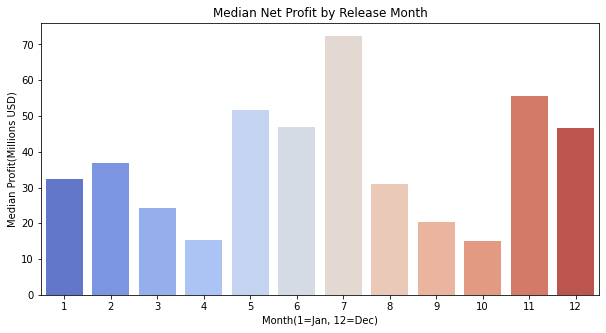

In [53]:
# In millions
plt.figure(figsize=(10,5))
sns.barplot(x=monthly_profit.index, y=monthly_profit.values, palette='coolwarm')
plt.title("Median Net Profit by Release Month")
plt.xlabel("Month(1=Jan, 12=Dec)")
plt.ylabel("Median Profit(Millions USD)")
plt.show()

We analyze the median profit by month to identify the best "Release Windows.

In [54]:
# Total revenue Yearly trends
yearly_total_revenue = bom.groupby('year')['total_revenue'].sum().sort_index() / 1_000_000
# In millions of dollars
# Is revenue growing over time
yearly_total_revenue

year
2010    25588.982880
2011    33693.990608
2012    39182.849338
2013    38294.995231
2014    39099.261732
2015    45921.703399
2016    48465.641429
2017    41793.812189
2018    38773.456760
Name: total_revenue, dtype: float64

In [55]:
# Studio performance
studio_perf= bom.groupby('studio')['total_revenue'].mean().sort_values(ascending=False).head(10)//1_000_000
# In millions of $
studio_perf

studio
HC          870.0
P/DW        507.0
BV          419.0
GrtIndia    254.0
WB (NL)     231.0
Fox         229.0
WB          225.0
Sony        206.0
Uni.        205.0
Par.        198.0
Name: total_revenue, dtype: float64

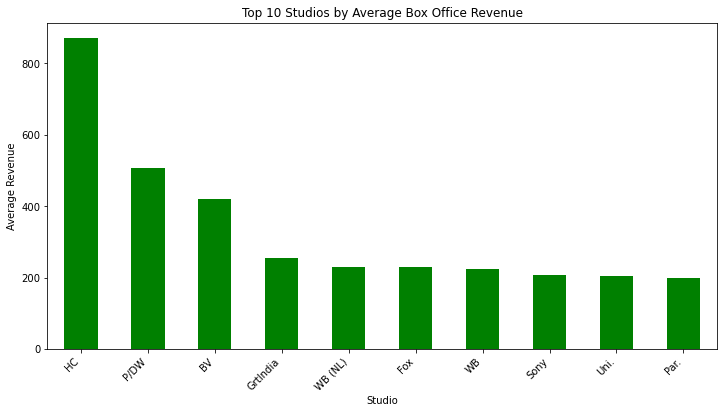

In [56]:
# Visualizing Studio performance based on average total revenue
plt.figure(figsize=(12,6))
studio_perf.plot(kind='bar', color='green')
plt.title("Top 10 Studios by Average Box Office Revenue")
plt.ylabel("Average Revenue")
plt.xlabel("Studio")
plt.xticks(rotation=45, ha='right')
plt.show()

The graph above analyzes the top 10 production studios in gross profit between 2010 to 2018. This shows the best peformers in the film industry, where our company can focus on the type of films they produce.

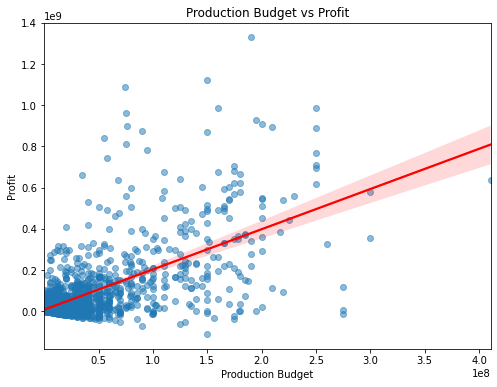

In [57]:
# Showing the relationship between production budget and profits
plt.figure(figsize=(8,6))
sns.regplot(
    x='production_budget',
    y='profit',
    data=merged_1,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)
plt.title("Production Budget vs Profit")
plt.xlabel("Production Budget")
plt.ylabel("Profit")
plt.show()

We use a redplot to see the "Line of Best Fit." This helps us understand if spending an extra $10M actually results in more revenue.s.
Insight: There is a "diminishing return" on very high budgets. The most consistent success happens in the $30M–$70M range.

In [58]:
# Total revenue Yearly trends
yearly_total_revenue = bom.groupby('year')['total_revenue'].sum().sort_index() / 1_000_000
# In millions of dollars
# Is revenue growing over time
yearly_total_revenue

year
2010    25588.982880
2011    33693.990608
2012    39182.849338
2013    38294.995231
2014    39099.261732
2015    45921.703399
2016    48465.641429
2017    41793.812189
2018    38773.456760
Name: total_revenue, dtype: float64

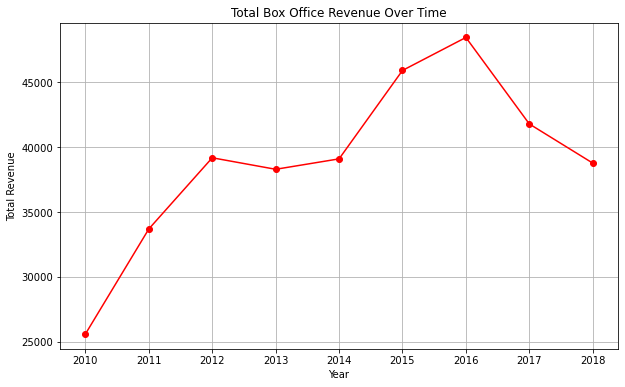

In [59]:
# Visualizing total yearly revenue
plt.figure(figsize=(10,6))
plt.plot(yearly_total_revenue.index, yearly_total_revenue.values, marker='o', color='red')
plt.title("Total Box Office Revenue Over Time")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.show()

The graph above analyses the total revenue generated by different movies over time.From the graph there is an increasing trend in the revenue from 2010 to 2016 however from 2017 the revenue declines.This implies that revenue should not solemnly be used in determining the genre to invest in.

**6.RECOMMENDATIONS**

1. Invest in High-Impact Productions  
   Since profits are concentrated among a few standout films, studios should prioritize projects with strong market potential, such as established franchises, sequels, or films with proven audience appeal.

2. Leverage Data-Driven Decision Making 
   Use historical profit data, genre trends, audience preferences, and release timing analysis to guide production and marketing strategies.

3. Optimize Marketing Strategies 
   Given the large profitability gap, aggressive and well-targeted marketing campaigns can help elevate a film’s performance into the highest profit tier.

4. Diversify Investment Portfolio  
   While aiming for blockbuster hits, studios should balance risk by investing in a mix of high-budget and mid-budget films to ensure more stable overall returns.

5. Analyze Key Success Drivers  
   Further analysis should be conducted on factors such as genre, production budget, release season, and star power to understand what differentiates the highest-profit films from the rest.

**7.CONCLUSION**

Analysis of box office data (primarily 2010–2018) reveals that Action, Adventure, Sci-Fi, and Animation genres consistently deliver the highest worldwide revenue and strongest international performance. Family animation and franchise-driven action-adventure films show particularly reliable returns, while mid-budget projects in the $25–60 million range achieve the best risk-adjusted ROI. Extremely high-budget films (> $150 M) produce both massive hits and costly flops, making disciplined budgeting essential.
Release timing strongly influences success: the May–July summer window and November–December holiday period generate the highest median profits due to school breaks, family audiences, and gift-giving seasons. Off-peak months (January–February, August–September) are best reserved for smaller releases, counter-programming, or streaming-focused titles.
Strategic recommendation: Build a core slate of 2–3 $40–70 million action-adventure or family animation films per year targeting summer and holiday windows, supplemented by 3–5 lower-budget ($10–40 M) projects for diversification and strong ancillary/streaming revenue. Selective $100 M+ tentpoles should only be pursued with proven franchise value, global star power, and robust international pre-sales. This balanced approach maximizes theatrical upside while controlling financial risk in a competitive market.